#exponential distribution

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('USGS Earthquakes 2024.csv')
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2024-01-26T04:52:42.967Z,31.604000,-104.213000,4.4198,1.7,ml,18.0,69.0,0.100000,0.50,...,2024-01-26T05:08:27.774Z,"51 km NW of Toyah, Texas",earthquake,0.00,1.292059,0.10,13.0,automatic,tx,tx
1,2024-01-26T04:42:50.711Z,64.501000,-146.905800,4.2000,1.4,ml,NaN,NaN,NaN,0.75,...,2024-01-26T05:01:12.516Z,"2 km S of Salcha, Alaska",earthquake,NaN,0.200000,NaN,NaN,automatic,ak,ak
2,2024-01-26T04:32:51.471Z,63.529000,-147.554300,13.1000,1.6,ml,NaN,NaN,NaN,0.62,...,2024-01-26T04:34:54.160Z,"71 km ESE of Denali Park, Alaska",earthquake,NaN,0.300000,NaN,NaN,automatic,ak,ak
3,2024-01-26T04:29:01.180Z,38.833168,-122.797165,1.7300,0.4,md,9.0,65.0,0.007468,0.02,...,2024-01-26T04:46:12.828Z,"6 km W of Cobb, CA",earthquake,0.34,0.970000,0.31,10.0,automatic,nc,nc
4,2024-01-26T04:23:14.444Z,63.546200,-150.971900,0.0000,1.2,ml,NaN,NaN,NaN,0.80,...,2024-01-26T04:25:43.831Z,"37 km E of Denali National Park, Alaska",earthquake,NaN,0.400000,NaN,NaN,automatic,ak,ak


Dataset: USGS Earthquake Catalog

Variable used: time

Derived variable: waiting time between consecutive earthquakes

Distribution studied: Exponential distribution

Reason: Exponential distribution is commonly used to model waiting time until the next event.

1. Basic idea

The exponential distribution is used to model the waiting time until the next event occurs.

In this dataset, the event is:

an earthquake with magnitude >= 4.5

So we calculate:

waiting time = time of next earthquake - time of previous earthquake

Then we estimate the exponential distribution rate parameter:

λ = 1 / mean waiting time

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# 1. Load dataset
# -------------------------------------------------------

df = pd.read_csv("USGS Earthquakes 2024.csv")

# Convert time column to datetime format
df["time"] = pd.to_datetime(df["time"])

# -------------------------------------------------------
# 2. Filter only real earthquake events
# -------------------------------------------------------

earthquakes = df[df["type"] == "earthquake"].copy()

# Use only stronger earthquakes for cleaner analysis
earthquakes = earthquakes[earthquakes["mag"] >= 4.5].copy()

# Sort by time from oldest to newest
earthquakes = earthquakes.sort_values("time")

# -------------------------------------------------------
# 3. Calculate waiting times between earthquakes
# -------------------------------------------------------

earthquakes["waiting_time_hours"] = earthquakes["time"].diff().dt.total_seconds() / 3600

# Remove the first missing value
waiting_times = earthquakes["waiting_time_hours"].dropna()

# -------------------------------------------------------
# 4. Estimate lambda from real waiting times
# -------------------------------------------------------

mean_waiting_time = waiting_times.mean()
lambda_rate = 1 / mean_waiting_time

print("Mean waiting time:", mean_waiting_time)
print("Estimated lambda:", lambda_rate)

# -------------------------------------------------------
# 5. Generate exponential samples
# -------------------------------------------------------

np.random.seed(42)

exponential_samples = np.random.exponential(
    scale=1/lambda_rate,
    size=len(waiting_times)
)

# -------------------------------------------------------
# 6. Compute mean and variance of generated samples
# -------------------------------------------------------

sample_mean = np.mean(exponential_samples)
sample_variance = np.var(exponential_samples, ddof=1)

theoretical_mean = 1 / lambda_rate
theoretical_variance = 1 / (lambda_rate ** 2)

print("\nGenerated Exponential Samples")
print("Sample mean:", sample_mean)
print("Sample variance:", sample_variance)

print("\nTheoretical Values")
print("Theoretical mean:", theoretical_mean)
print("Theoretical variance:", theoretical_variance)

Mean waiting time: 1.434223376753507
Estimated lambda: 0.6972414591816161

Generated Exponential Samples
Sample mean: 1.430977617111309
Sample variance: 1.9109123826409309

Theoretical Values
Theoretical mean: 1.434223376753507
Theoretical variance: 2.0569966944262323


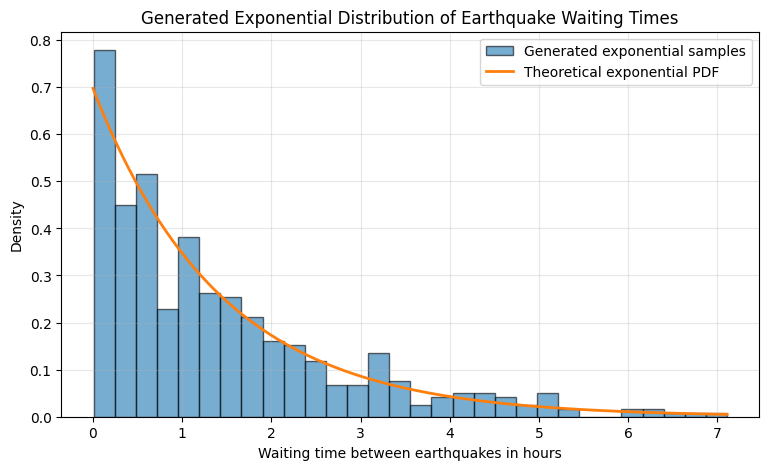

In [7]:
# -------------------------------------------------------
# 7. Visualize exponential distribution
# -------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.hist(
    exponential_samples,
    bins=30,
    density=True,
    alpha=0.6,
    edgecolor="black",
    label="Generated exponential samples"
)

# Create theoretical exponential PDF curve
x = np.linspace(0, exponential_samples.max(), 500)
pdf = lambda_rate * np.exp(-lambda_rate * x)

plt.plot(
    x,
    pdf,
    linewidth=2,
    label="Theoretical exponential PDF"
)

plt.title("Generated Exponential Distribution of Earthquake Waiting Times")
plt.xlabel("Waiting time between earthquakes in hours")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

4. What the graph shows

The histogram shows the generated waiting times.

The curve shows the theoretical exponential distribution based on the estimated λ.

A typical exponential distribution has:

many short waiting times

few long waiting times

right-skewed shape


This makes sense for event-based data because many events may happen after a short waiting period, while very long waiting periods are less common.

Mean and variance explanation

For an exponential distribution:

Mean = 1 / λ

Variance = 1 / λ²


| Measure  | Meaning                                        |
| -------- | ---------------------------------------------- |
| Mean     | Average waiting time until the next earthquake |
| Variance | How spread out the waiting times are           |
| λ        | Average earthquake occurrence rate             |


For your dataset, using earthquakes with magnitude >= 4.5, the mean waiting time is around:

1.43 hours

So the estimated rate is approximately:

λ = 0.697 earthquakes per hour